### Imports ###

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix
import optuna

In [2]:
from indoor_plant_preprocessing import preprocessing
data, data_optimal = preprocessing()
display(data)
display(data_optimal)

,Plant_ID,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Optimal_Room_Temperature_C,Optimal_Humidity_%,Optimal_Soil_Moisture_%,Optimal_Light_Intensity_Lux,Light_Intensity,Pump_time,soil_deficit,temp_deviation,air_hum_deficit,light_deviation,et_approx
0,Sansevieria cylindrica,21.7,77.5,51.9,24,35,25,466,802,20.5,-26.9,-2.3,-42.5,336,221.699363
1,Aloe vera,22.6,68.9,28.2,24,35,25,850,970,19.1,-3.2,-1.4,-33.9,120,313.619456
2,Ficus lyrata,17.2,44.3,13.6,24,50,45,850,306,47.7,31.4,-6.8,5.7,-544,116.185430
3,Monstera deliciosa,25.0,72.2,38.4,25,70,65,650,121,20.7,26.6,0.0,-2.2,-529,41.325137
4,Ficus lyrata,23.2,51.6,37.9,24,50,45,850,520,46.5,7.1,-0.8,-1.6,-330,229.353612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,Sansevieria cylindrica,32.4,58.0,31.7,24,35,25,466,981,37.0,-6.7,8.4,-23.0,515,538.718644
996,Schefflera arboricola,24.3,39.4,32.9,23,50,45,633,957,9.1,12.1,1.3,10.6,324,575.621287
997,Monstera deliciosa,26.4,52.4,58.5,25,70,65,650,861,13.4,6.5,1.4,17.6,211,425.662921
998,Epipremnum aureum,18.7,60.1,24.8,24,60,55,400,786,44.2,30.2,-5.3,-0.1,386,240.559738


,Plant_ID,Optimal_Room_Temperature_C,Optimal_Humidity_%,Optimal_Soil_Moisture_%,Optimal_Light_Intensity_Lux
0,Aglaonema commutatum,24,60,55,350
1,Aloe vera,24,35,25,850
2,Anthurium andraeanum,25,75,65,650
3,Begonia maculata,23,65,60,550
4,Calathea orbifolia,24,75,70,300
5,Chlorophytum comosum,22,55,50,450
6,Codiaeum variegatum,25,60,55,900
7,Dieffenbachia seguine,24,65,60,500
8,Dracaena trifasciata,23,40,30,700
9,Epipremnum aureum,24,60,55,400


### Clustering Ward's Method ###

In [3]:
optimal_features = [
    "Optimal_Room_Temperature_C",
    "Optimal_Humidity_%",
    "Optimal_Soil_Moisture_%",
    "Optimal_Light_Intensity_Lux"
]

scaler_optimal = StandardScaler()
data_optimal_scaled = data_optimal.copy()

optimal_X_scaled = pd.DataFrame(
    scaler_optimal.fit_transform(data_optimal_scaled[optimal_features]),
    columns=optimal_features,
    index=data_optimal_scaled.index
)

optimal_X_scaled

,Optimal_Room_Temperature_C,Optimal_Humidity_%,Optimal_Soil_Moisture_%,Optimal_Light_Intensity_Lux
0,0.356034,0.210183,0.291077,-0.818911
1,0.356034,-1.700568,-1.763585,1.716416
2,1.542816,1.356633,0.975964,0.702286
3,-0.830747,0.592333,0.633521,0.195220
4,0.356034,1.356633,1.318408,-1.072443
5,-2.017529,-0.171968,-0.051367,-0.311845
6,1.542816,0.210183,0.291077,1.969949
7,0.356034,0.592333,0.633521,-0.058313
8,-0.830747,-1.318418,-1.421141,0.955818
9,0.356034,0.210183,0.291077,-0.565378


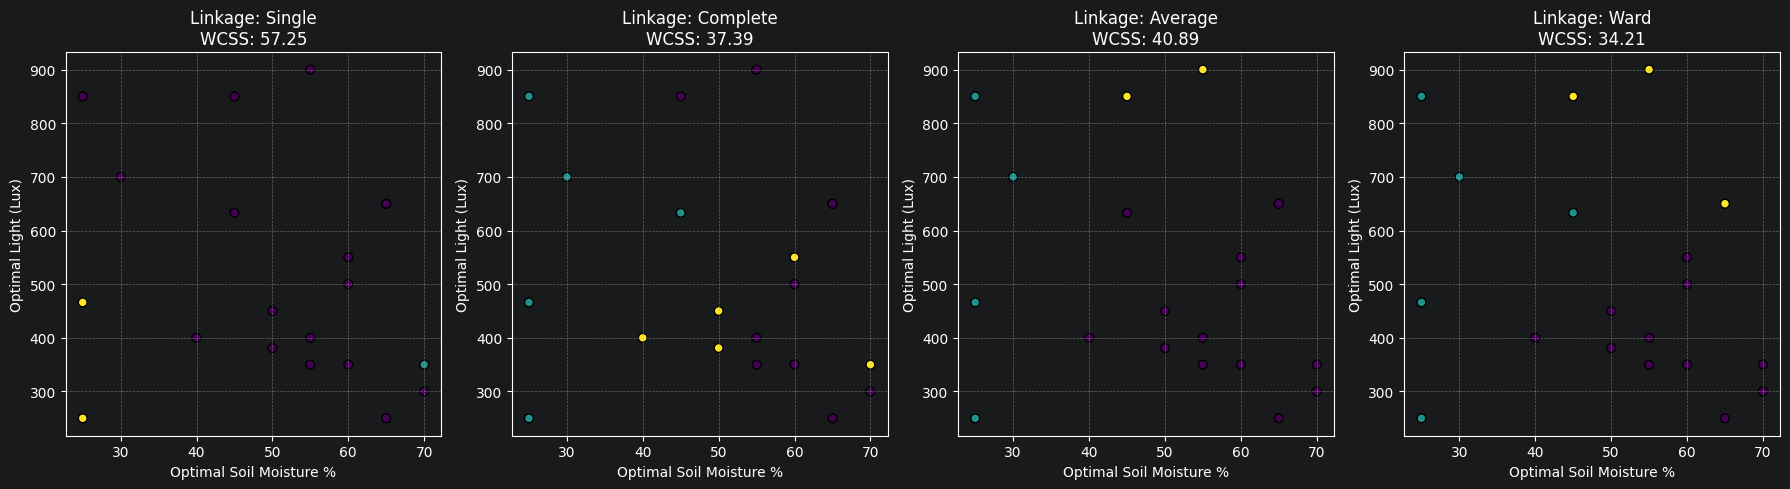

In [4]:
from sklearn.cluster import AgglomerativeClustering

# Different linkage methods (measure of distance between clusters)
methods = ['single', 'complete', 'average', 'ward']
plt.figure(figsize=(18, 5))
for i, link in enumerate(methods):
    model = AgglomerativeClustering(n_clusters=3, linkage=link)
    labels = model.fit_predict(optimal_X_scaled)
    # WCSS (within cluster sum of squares)
    wcss = 0
    for cluster_id in range(3):
        cluster_points = optimal_X_scaled[labels == cluster_id]
        centroid = cluster_points.mean(axis=0)
        wcss += np.sum((cluster_points - centroid) ** 2)

    plt.subplot(1, 4, i + 1)
    plt.scatter(data_optimal["Optimal_Soil_Moisture_%"], data_optimal["Optimal_Light_Intensity_Lux"], c=labels, cmap='viridis', s=40, edgecolors='k')
    plt.title(f"Linkage: {link.capitalize()}\nWCSS: {wcss:.2f}")
    plt.xlabel("Optimal Soil Moisture %")
    plt.ylabel("Optimal Light (Lux)")
    plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

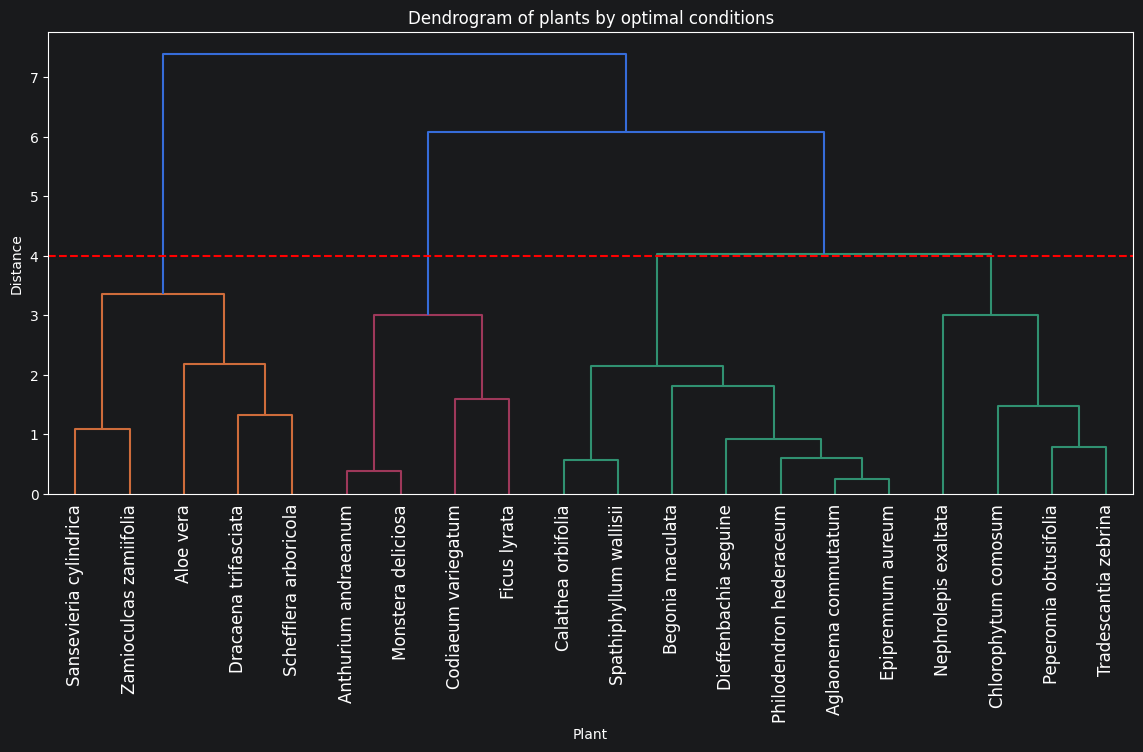

In [5]:
# Ward's method
Z = linkage(optimal_X_scaled, method='ward')
plt.figure(figsize=(14, 6))
dendrogram(Z, labels=data_optimal['Plant_ID'].values, leaf_rotation=90)
plt.axhline(y=4, color='r', linestyle='--')
plt.title("Dendrogram of plants by optimal conditions")
plt.xlabel("Plant")
plt.ylabel("Distance")
plt.show()

In [6]:
K = 3
model = AgglomerativeClustering(n_clusters=K, linkage='ward').fit(optimal_X_scaled)
data_optimal['care_group'] = model.labels_

# Profile each cluster
profile = data_optimal.groupby('care_group')[optimal_features].mean().round(1)
profile['n_plants'] = data_optimal.groupby('care_group').size()
profile

,Optimal_Room_Temperature_C,Optimal_Humidity_%,Optimal_Soil_Moisture_%,Optimal_Light_Intensity_Lux,n_plants
care_group,,,,,
0,23.4,63.2,57.7,389.2,11
1,23.6,39.0,30.0,579.8,5
2,24.8,63.8,57.5,762.5,4


In [7]:
# Plants per group
for g in sorted(data_optimal['care_group'].unique()):
    plants = data_optimal[data_optimal['care_group'] == g]['Plant_ID'].tolist()
    print(f"Group {g} ({len(plants)} plants): {plants}")

Group 0 (11 plants): ['Aglaonema commutatum', 'Begonia maculata', 'Calathea orbifolia', 'Chlorophytum comosum', 'Dieffenbachia seguine', 'Epipremnum aureum', 'Nephrolepis exaltata', 'Peperomia obtusifolia', 'Philodendron hederaceum', 'Spathiphyllum wallisii', 'Tradescantia zebrina']
Group 1 (5 plants): ['Aloe vera', 'Dracaena trifasciata', 'Sansevieria cylindrica', 'Schefflera arboricola', 'Zamioculcas zamiifolia']
Group 2 (4 plants): ['Anthurium andraeanum', 'Codiaeum variegatum', 'Ficus lyrata', 'Monstera deliciosa']


In [8]:
# Human-readable labels based on the profiles
group_labels = {
    0: "Cool-temperate moderate",  # cooler, moderate everything
    1: "Succulent / dry-loving",   # warm, dry air, dry soil, bright
    2: "Shade-tolerant tropical",  # warm, humid, low light
}
profile['label'] = profile.index.map(group_labels)
profile[['n_plants', 'label']]

,n_plants,label
care_group,,
0,11,Cool-temperate moderate
1,5,Succulent / dry-loving
2,4,Shade-tolerant tropical


### Feature Engineering for Classification ###

In [9]:
# Bring the cluster label from data_optimal into the main data
data = data.merge(
    data_optimal[['Plant_ID', 'care_group']],
    on='Plant_ID',
    how='left'
)

# Drop optimal columns and Plant_ID (so the model can't cheat)
data_model = data.drop(columns=["Optimal_Humidity_%", "Optimal_Room_Temperature_C",
                                "Optimal_Soil_Moisture_%", "Optimal_Light_Intensity_Lux",
                                "Plant_ID"])
data_model

,Room_Temperature_C,Humidity_%,Soil_Moisture_%,Light_Intensity,Pump_time,soil_deficit,temp_deviation,air_hum_deficit,light_deviation,et_approx,care_group
0,21.7,77.5,51.9,802,20.5,-26.9,-2.3,-42.5,336,221.699363,1
1,22.6,68.9,28.2,970,19.1,-3.2,-1.4,-33.9,120,313.619456,1
2,17.2,44.3,13.6,306,47.7,31.4,-6.8,5.7,-544,116.185430,2
3,25.0,72.2,38.4,121,20.7,26.6,0.0,-2.2,-529,41.325137,2
4,23.2,51.6,37.9,520,46.5,7.1,-0.8,-1.6,-330,229.353612,2
...,...,...,...,...,...,...,...,...,...,...,...
995,32.4,58.0,31.7,981,37.0,-6.7,8.4,-23.0,515,538.718644,1
996,24.3,39.4,32.9,957,9.1,12.1,1.3,10.6,324,575.621287,1
997,26.4,52.4,58.5,861,13.4,6.5,1.4,17.6,211,425.662921,2
998,18.7,60.1,24.8,786,44.2,30.2,-5.3,-0.1,386,240.559738,0


In [10]:
X = data_model.drop(columns=["care_group"])
y = data_model["care_group"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Features: {list(X.columns)}")
print(f"Class distribution:\n{y.value_counts().sort_index()}")

Features: ['Room_Temperature_C', 'Humidity_%', 'Soil_Moisture_%', 'Light_Intensity', 'Pump_time', 'soil_deficit', 'temp_deviation', 'air_hum_deficit', 'light_deviation', 'et_approx']
Class distribution:
care_group
0    540
1    263
2    197
Name: count, dtype: int64


In [11]:
def objective(trial):

    params = {
        "n_estimators": trial.suggest_int(
            "n_estimators", 50, 500
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 2, 7
        ),

        "min_samples_split": trial.suggest_int(
            "min_samples_split", 2, 20
        ),

        "min_samples_leaf": trial.suggest_int(
            "min_samples_leaf", 1, 10
        ),

        "max_features": trial.suggest_categorical(
            "max_features",
            ["sqrt", "log2", None]
        ),

        "random_state": 42,
        "n_jobs": -1,
    }

    model = RandomForestClassifier(**params)

    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )

    cv_results = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        return_train_score=True,
        n_jobs=-1,
    )

    train_score = cv_results["train_score"].mean()
    val_score = cv_results["test_score"].mean()
    val_std = cv_results["test_score"].std()

    # Overfitting gap (train - val). Bigger gap = more overfit.
    gap = train_score - val_score

    # Penalty weights — tune these to taste.
    LAMBDA_GAP = 0.5   # how harshly to punish the train/val gap
    LAMBDA_STD = 0.1   # how harshly to punish unstable folds

    penalty = LAMBDA_GAP * gap + LAMBDA_STD * val_std

    # Log for inspection
    trial.set_user_attr("train_score", train_score)
    trial.set_user_attr("val_score", val_score)
    trial.set_user_attr("gap", gap)
    trial.set_user_attr("val_std", val_std)

    return val_score - penalty

In [12]:
study = optuna.create_study(direction="maximize")

study.optimize(
    objective,
    n_trials=50,
    show_progress_bar=True
)

[I 2026-05-18 19:56:15,320] A new study created in memory with name: no-name-733c6f3c-bca2-48ab-8939-b7cf859c1167


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-18 19:56:18,595] Trial 0 finished with value: 0.8097209828131703 and parameters: {'n_estimators': 85, 'max_depth': 7, 'min_samples_split': 8, 'min_samples_leaf': 8, 'max_features': None}. Best is trial 0 with value: 0.8097209828131703.
[I 2026-05-18 19:56:22,225] Trial 1 finished with value: 0.773231657230259 and parameters: {'n_estimators': 396, 'max_depth': 6, 'min_samples_split': 4, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.8097209828131703.
[I 2026-05-18 19:56:23,215] Trial 2 finished with value: 0.7101003128959609 and parameters: {'n_estimators': 194, 'max_depth': 3, 'min_samples_split': 8, 'min_samples_leaf': 6, 'max_features': None}. Best is trial 0 with value: 0.8097209828131703.
[I 2026-05-18 19:56:23,653] Trial 3 finished with value: 0.7029466618742255 and parameters: {'n_estimators': 81, 'max_depth': 4, 'min_samples_split': 6, 'min_samples_leaf': 1, 'max_features': 'log2'}. Best is trial 0 with value: 0.8097209828131703.
[I 2026

In [13]:
print("Best parameters:")
print(study.best_params)

print(f"\nBest CV accuracy: {study.best_value:.3f}")

Best parameters:
{'n_estimators': 50, 'max_depth': 7, 'min_samples_split': 9, 'min_samples_leaf': 8, 'max_features': None}

Best CV accuracy: 0.816


In [14]:
best_rf = RandomForestClassifier(
    **study.best_params,
    random_state=42
)

best_rf.fit(X_train, y_train);
train_acc = best_rf.score(X_train, y_train)
test_acc = best_rf.score(X_test, y_test)

print(f"Train accuracy: {train_acc:.3f}")
print(f"Test accuracy:  {test_acc:.3f}")

Train accuracy: 0.927
Test accuracy:  0.885


In [15]:
# Per-group classification report
preds = best_rf.predict(X_test)
print(classification_report(y_test, preds, digits=3))

              precision    recall  f1-score   support

           0      0.916     0.907     0.912       108
           1      0.855     0.887     0.870        53
           2      0.842     0.821     0.831        39

    accuracy                          0.885       200
   macro avg      0.871     0.872     0.871       200
weighted avg      0.885     0.885     0.885       200



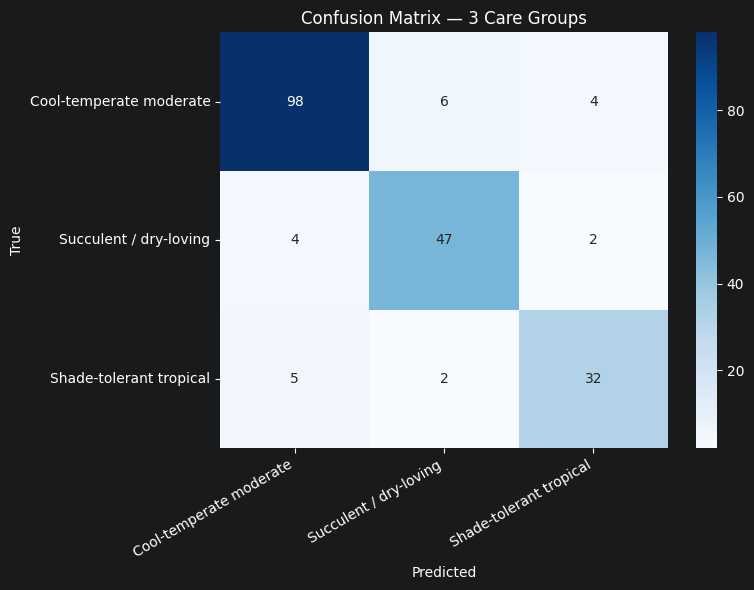

In [16]:
# Confusion matrix
cm = confusion_matrix(y_test, preds)
group_names = [group_labels[g] for g in sorted(group_labels.keys())]

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=group_names, yticklabels=group_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title(f'Confusion Matrix — {K} Care Groups')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

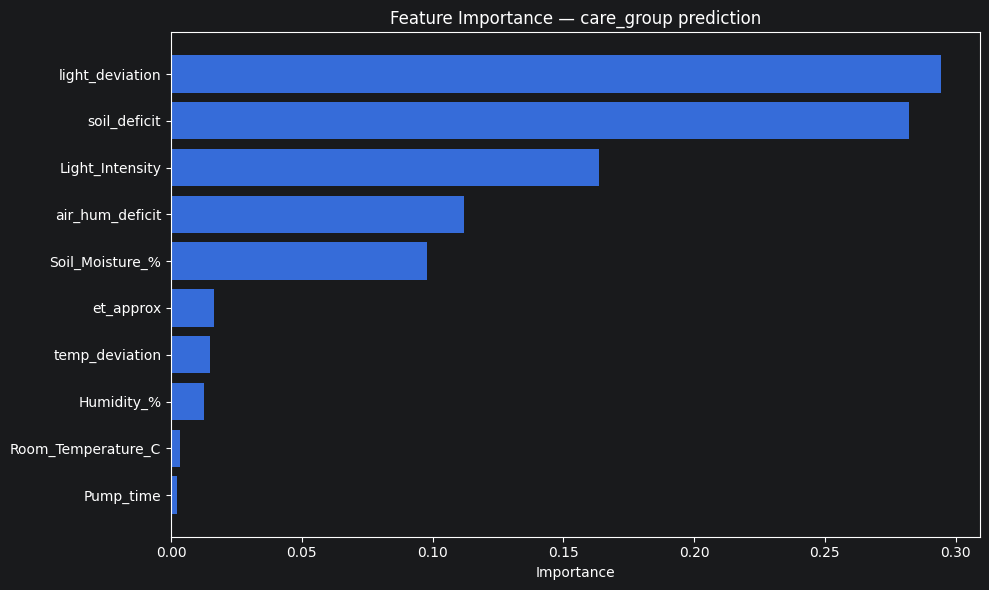

,Feature,Importance
8,light_deviation,0.294613
5,soil_deficit,0.282099
3,Light_Intensity,0.163490
7,air_hum_deficit,0.112188
2,Soil_Moisture_%,0.097709
9,et_approx,0.016402
6,temp_deviation,0.015007
1,Humidity_%,0.012694
0,Room_Temperature_C,0.003354
4,Pump_time,0.002444


In [17]:
# Feature importance
fi = pd.DataFrame({"Feature": X.columns, "Importance": best_rf.feature_importances_})
fi = fi.sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(fi["Feature"], fi["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance — care_group prediction")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

fi